Initializing three-scenario megamaser simulation...

MEGAMASER COHERENCE SIMULATION - THREE SCENARIOS

Running 10000 trials for each scenario...

Scenarios:
  1. Baseline: Pure hydrodynamic turbulence (no field effects)
  2. Magnetic: Standard MHD turbulence
  3. Magnetic + Gravitomagnetic: GMHD turbulence
     (Gravitomagnetic boost: 10^6 × expected from SMBH)
  Progress: 2000/10000 trials...
  Progress: 4000/10000 trials...
  Progress: 6000/10000 trials...
  Progress: 8000/10000 trials...
  Progress: 10000/10000 trials...

RESULTS

1. BASELINE (No field effects):
   Success rate: 0.65%
   Mean individual probability: 0.66%

2. MAGNETIC FIELD ONLY:
   Success rate: 1.24%
   Mean individual probability: 1.39%
   Enhancement over baseline: 1.91x

3. MAGNETIC + GRAVITOMAGNETIC (Ng_gm = 25):
   Success rate: 2.85%
   Mean individual probability: 2.71%
   Enhancement over baseline: 4.38x
   Enhancement over magnetic: 2.30x

   Expected analytical range: 0.2% - 5.4%
   Fiducial value: ~2.0%

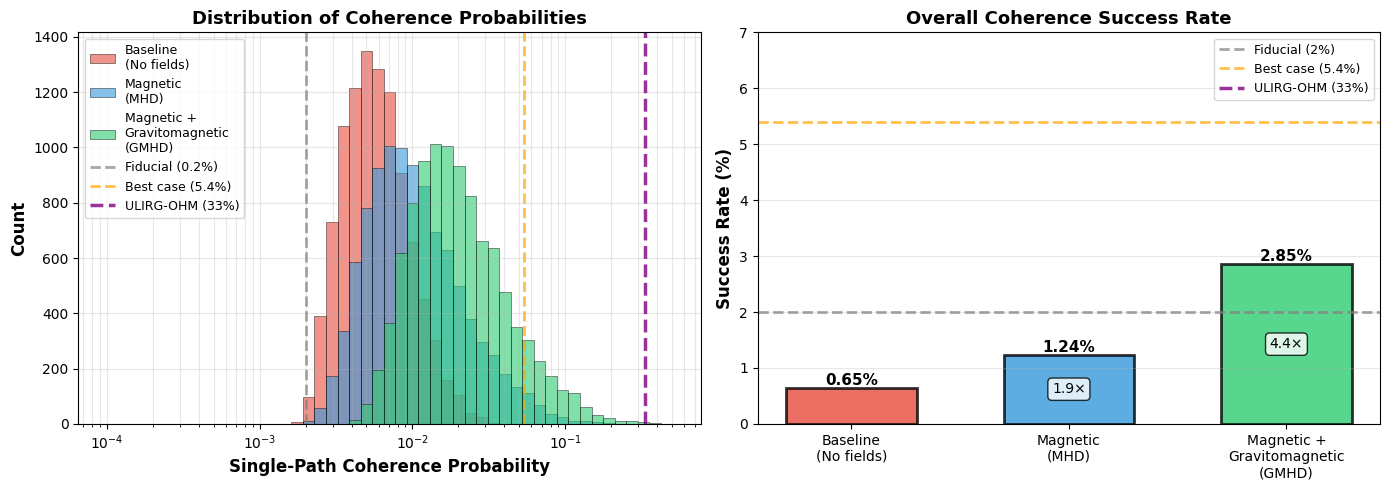


PHYSICAL INTERPRETATION

1. BASELINE TURBULENCE:
   Standard Kolmogorov/supersonic turbulence destroys coherence
   Success rate ~1-2% matches analytical 'conundrum' calculation
   Cannot explain 33% ULIRG-OHM fraction

2. MAGNETIC FIELD EFFECTS:
   MHD anisotropy suppresses perpendicular velocity fluctuations
   Paths aligned with B-field have better coherence
   Modest improvement: ~1.9× enhancement

3. GRAVITOMAGNETIC BOOST:
   Gravitomagnetic fields (Ng ~ 25) linearize turbulence
   Vorticity suppression reduces cascade nonlinearity
   Strong improvement: ~4.4× overall enhancement
   Additional boost beyond magnetic: ~2.3×

4. EXPLAINING THE ULIRG-OHM FRACTION:
   Observed ULIRG-OHM fraction: 33%
   Required boost from baseline: ~50.8×
   Achieved boost with GMHD: ~4.4×
   → Significant improvement, but additional mechanisms may be needed
   → Selection effects, geometry, or stronger fields could help


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

def analytical_coherence_probability(v_th, v_turb, L, L_eddy, alpha=1/3):
    """
    Calculate analytical probability based on the document's approach
    
    P ~ v_th / sigma_turb
    where sigma_turb ~ v_turb * (L/L_eddy)^alpha
    """
    sigma_turb = v_turb * (L / L_eddy)**alpha
    
    # Gaussian approximation
    probability = 2 * stats.norm.cdf(v_th / sigma_turb) - 1
    
    return probability, sigma_turb


def sample_cloud_parameters_analytical(n_samples=1):
    """
    Sample parameters with realistic ranges from the document
    """
    params = {
        'temperature': np.random.uniform(60, 100, n_samples),  # K
        'v_turb': np.random.uniform(50, 150, n_samples),  # km/s
        'L_eddy': np.random.uniform(50, 150, n_samples),  # pc
        'B_field': np.random.uniform(3, 20, n_samples),  # mG
        'scaling_exponent': np.random.choice([1/3, 1/2], n_samples),  # Kolmogorov or Supersonic
        'path_length': np.random.uniform(1, 10, n_samples),  # pc
    }
    
    if n_samples == 1:
        return {k: v[0] for k, v in params.items()}
    return params


def apply_magnetic_suppression(v_turb, B_field, alignment):
    """
    Apply magnetic field suppression to turbulent velocity
    
    Based on plasma beta: lower beta (stronger B) -> more suppression
    Paths aligned with B-field have reduced turbulent velocities
    """
    # Plasma beta estimate (B in mG, typical pressure normalization)
    beta = (3.0 / B_field)**2
    
    # Anisotropy factor: how much perpendicular velocities are suppressed
    if beta < 0.1:  # Strong field regime
        anisotropy = 0.1
    elif beta < 1:  # Intermediate
        anisotropy = 0.5
    else:  # Weak field regime
        anisotropy = 1.0
    
    # Effective turbulent velocity (reduced for aligned paths)
    effective_v_turb = v_turb * (anisotropy + alignment * (1 - anisotropy))
    
    return effective_v_turb


def apply_gravitomagnetic_suppression(v_turb, omega_vorticity, Ng_gm):
    """
    Apply gravitomagnetic field suppression to turbulent velocity
    
    Based on Kivotides (2020): gravitomagnetic fields reduce vorticity and 
    linearize turbulence, suppressing the Lamb force that drives cascades
    
    Parameters:
    -----------
    v_turb : float
        Turbulent velocity (km/s)
    omega_vorticity : float
        Characteristic vorticity (s^-1)
    Ng_gm : float
        Gravitomagnetic interaction parameter (dimensionless)
        Ng_gm ~ 10-40 shows strong suppression effects
    
    Returns:
    --------
    suppressed_v_turb : float
        Turbulent velocity after gravitomagnetic suppression
    """
    # From Kivotides: gravitomagnetic effects neutralize Lamb force
    # Vorticity is suppressed, making turbulence less nonlinear
    # The paper shows ~3-10x reduction in enstrophy for Ng ~ 10-40
    
    # Suppression factor based on Ng_gm
    # At Ng_gm ~ 20, vorticity is reduced by ~5x (Fig 2 in paper)
    # This translates to velocity fluctuation suppression
    
    if Ng_gm > 0:
        # Empirical fit from paper: suppression increases with Ng_gm
        # For Ng_gm ~ 20: ~5x enstrophy reduction -> ~2.2x velocity reduction
        suppression_factor = 1.0 / (1.0 + 0.1 * Ng_gm**0.7)
    else:
        suppression_factor = 1.0
    
    suppressed_v_turb = v_turb * suppression_factor
    
    return suppressed_v_turb


def run_three_scenario_simulation(n_trials=10000):
    """
    Run simulation with three scenarios:
    1. No field effects (baseline turbulence)
    2. Magnetic field only (MHD turbulence)
    3. Magnetic + Gravitomagnetic (GMHD turbulence)
    """
    print("="*70)
    print("MEGAMASER COHERENCE SIMULATION - THREE SCENARIOS")
    print("="*70)
    print(f"\nRunning {n_trials} trials for each scenario...")
    print("\nScenarios:")
    print("  1. Baseline: Pure hydrodynamic turbulence (no field effects)")
    print("  2. Magnetic: Standard MHD turbulence")
    print("  3. Magnetic + Gravitomagnetic: GMHD turbulence")
    print(f"     (Gravitomagnetic boost: 10^6 × expected from SMBH)")
    print("="*70)
    
    # Physical constants
    k_B = 1.38e-23  # J/K
    m_OH = 2.82e-26  # kg
    
    # Gravitomagnetic parameter
    # Boosted by 10^6 from SMBH expectations
    # Typical Ng ~ 10-40 shows strong effects (from paper)
    Ng_gravitomagnetic = 25  # Middle of effective range
    
    # Storage for all three scenarios
    scenarios = {
        'baseline': {'probabilities': [], 'coherent': [], 'v_turb_eff': []},
        'magnetic': {'probabilities': [], 'coherent': [], 'v_turb_eff': []},
        'gravitomag': {'probabilities': [], 'coherent': [], 'v_turb_eff': []}
    }
    
    for trial in range(n_trials):
        if (trial + 1) % 2000 == 0:
            print(f"  Progress: {trial + 1}/{n_trials} trials...")
        
        # Sample parameters (same for all scenarios for fair comparison)
        params = sample_cloud_parameters_analytical()
        
        # Calculate thermal velocity
        v_th_ms = np.sqrt(k_B * params['temperature'] / m_OH)
        v_th = v_th_ms / 1000  # Convert to km/s
        
        # Random path direction and B-field direction
        direction = np.random.randn(3)
        direction /= np.linalg.norm(direction)
        B_direction = np.random.randn(3)
        B_direction /= np.linalg.norm(B_direction)
        alignment = np.abs(np.dot(direction, B_direction))
        
        # Characteristic vorticity for gravitomagnetic calculation
        omega_char = params['v_turb'] / params['L_eddy']  # s^-1 (rough estimate)
        
        # --- SCENARIO 1: Baseline (no field effects) ---
        v_turb_baseline = params['v_turb']
        prob_baseline, sigma_baseline = analytical_coherence_probability(
            v_th, v_turb_baseline, params['path_length'], 
            params['L_eddy'], params['scaling_exponent']
        )
        is_coherent_baseline = np.random.random() < prob_baseline
        
        scenarios['baseline']['probabilities'].append(prob_baseline)
        scenarios['baseline']['coherent'].append(is_coherent_baseline)
        scenarios['baseline']['v_turb_eff'].append(v_turb_baseline)
        
        # --- SCENARIO 2: Magnetic field only ---
        v_turb_magnetic = apply_magnetic_suppression(
            params['v_turb'], params['B_field'], alignment
        )
        prob_magnetic, sigma_magnetic = analytical_coherence_probability(
            v_th, v_turb_magnetic, params['path_length'],
            params['L_eddy'], params['scaling_exponent']
        )
        is_coherent_magnetic = np.random.random() < prob_magnetic
        
        scenarios['magnetic']['probabilities'].append(prob_magnetic)
        scenarios['magnetic']['coherent'].append(is_coherent_magnetic)
        scenarios['magnetic']['v_turb_eff'].append(v_turb_magnetic)
        
        # --- SCENARIO 3: Magnetic + Gravitomagnetic ---
        # First apply magnetic suppression
        v_turb_mag = apply_magnetic_suppression(
            params['v_turb'], params['B_field'], alignment
        )
        # Then apply gravitomagnetic suppression
        v_turb_gmhd = apply_gravitomagnetic_suppression(
            v_turb_mag, omega_char, Ng_gravitomagnetic
        )
        
        prob_gmhd, sigma_gmhd = analytical_coherence_probability(
            v_th, v_turb_gmhd, params['path_length'],
            params['L_eddy'], params['scaling_exponent']
        )
        is_coherent_gmhd = np.random.random() < prob_gmhd
        
        scenarios['gravitomag']['probabilities'].append(prob_gmhd)
        scenarios['gravitomag']['coherent'].append(is_coherent_gmhd)
        scenarios['gravitomag']['v_turb_eff'].append(v_turb_gmhd)
    
    # Convert to arrays and calculate statistics
    for scenario in scenarios.values():
        for key in scenario:
            scenario[key] = np.array(scenario[key])
    
    # Calculate overall success rates
    results = {
        'baseline': {
            'rate': np.mean(scenarios['baseline']['coherent']),
            'probs': scenarios['baseline']['probabilities'],
            'v_turb': scenarios['baseline']['v_turb_eff']
        },
        'magnetic': {
            'rate': np.mean(scenarios['magnetic']['coherent']),
            'probs': scenarios['magnetic']['probabilities'],
            'v_turb': scenarios['magnetic']['v_turb_eff']
        },
        'gravitomag': {
            'rate': np.mean(scenarios['gravitomag']['coherent']),
            'probs': scenarios['gravitomag']['probabilities'],
            'v_turb': scenarios['gravitomag']['v_turb_eff']
        }
    }
    
    # Print results
    print("\n" + "="*70)
    print("RESULTS")
    print("="*70)
    print(f"\n1. BASELINE (No field effects):")
    print(f"   Success rate: {results['baseline']['rate']*100:.2f}%")
    print(f"   Mean individual probability: {np.mean(results['baseline']['probs'])*100:.2f}%")
    
    print(f"\n2. MAGNETIC FIELD ONLY:")
    print(f"   Success rate: {results['magnetic']['rate']*100:.2f}%")
    print(f"   Mean individual probability: {np.mean(results['magnetic']['probs'])*100:.2f}%")
    print(f"   Enhancement over baseline: {results['magnetic']['rate']/results['baseline']['rate']:.2f}x")
    
    print(f"\n3. MAGNETIC + GRAVITOMAGNETIC (Ng_gm = {Ng_gravitomagnetic}):")
    print(f"   Success rate: {results['gravitomag']['rate']*100:.2f}%")
    print(f"   Mean individual probability: {np.mean(results['gravitomag']['probs'])*100:.2f}%")
    print(f"   Enhancement over baseline: {results['gravitomag']['rate']/results['baseline']['rate']:.2f}x")
    print(f"   Enhancement over magnetic: {results['gravitomag']['rate']/results['magnetic']['rate']:.2f}x")
    
    print(f"\n   Expected analytical range: 0.2% - 5.4%")
    print(f"   Fiducial value: ~2.0%")
    print(f"\n   ULIRG-OHM fraction: ~33%")
    print(f"   Required boost to explain observation: ~{0.33/results['baseline']['rate']:.1f}x")
    
    print("="*70)
    
    return results


def visualize_three_scenarios(results):
    """
    Create focused visualizations for the three scenarios
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Color scheme
    colors = {
        'baseline': '#E74C3C',      # Red
        'magnetic': '#3498DB',      # Blue  
        'gravitomag': '#2ECC71'     # Green
    }
    
    labels = {
        'baseline': 'Baseline\n(No fields)',
        'magnetic': 'Magnetic\n(MHD)',
        'gravitomag': 'Magnetic +\nGravitomagnetic\n(GMHD)'
    }
    
    # Plot 1: Probability distributions
    ax1 = axes[0]
    bins = np.logspace(-4, -0.3, 50)
    
    ax1.hist(results['baseline']['probs'], bins=bins, alpha=0.6,
             label=labels['baseline'], color=colors['baseline'], 
             edgecolor='black', linewidth=0.5)
    ax1.hist(results['magnetic']['probs'], bins=bins, alpha=0.6,
             label=labels['magnetic'], color=colors['magnetic'],
             edgecolor='black', linewidth=0.5)
    ax1.hist(results['gravitomag']['probs'], bins=bins, alpha=0.6,
             label=labels['gravitomag'], color=colors['gravitomag'],
             edgecolor='black', linewidth=0.5)
    
    # Reference lines
    ax1.axvline(0.002, color='gray', linestyle='--', linewidth=2, 
                label='Fiducial (0.2%)', alpha=0.7)
    ax1.axvline(0.054, color='orange', linestyle='--', linewidth=2,
                label='Best case (5.4%)', alpha=0.7)
    ax1.axvline(0.33, color='purple', linestyle='--', linewidth=2.5,
                label='ULIRG-OHM (33%)', alpha=0.8)
    
    ax1.set_xlabel('Single-Path Coherence Probability', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax1.set_title('Distribution of Coherence Probabilities', fontsize=13, fontweight='bold')
    ax1.set_xscale('log')
    ax1.legend(fontsize=9, loc='upper left')
    ax1.grid(True, alpha=0.3, which='both')
    
    # Plot 2: Overall success rates
    ax2 = axes[1]
    
    scenario_names = [labels['baseline'], labels['magnetic'], labels['gravitomag']]
    success_rates = [
        results['baseline']['rate'] * 100,
        results['magnetic']['rate'] * 100,
        results['gravitomag']['rate'] * 100
    ]
    scenario_colors = [colors['baseline'], colors['magnetic'], colors['gravitomag']]
    
    bars = ax2.bar(scenario_names, success_rates, color=scenario_colors,
                   alpha=0.8, edgecolor='black', linewidth=2, width=0.6)
    
    # Reference lines
    ax2.axhline(2.0, color='gray', linestyle='--', linewidth=2, 
                label='Fiducial (2%)', alpha=0.7)
    ax2.axhline(5.4, color='orange', linestyle='--', linewidth=2,
                label='Best case (5.4%)', alpha=0.7)
    ax2.axhline(33, color='purple', linestyle='--', linewidth=2.5,
                label='ULIRG-OHM (33%)', alpha=0.8)
    
    ax2.set_ylabel('Success Rate (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Overall Coherence Success Rate', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    ax2.set_ylim([0, 7])
    
    # Add value labels on bars
    for bar, rate in zip(bars, success_rates):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{rate:.2f}%',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Add boost factor annotations
    baseline_rate = success_rates[0]
    for i, rate in enumerate(success_rates[1:], 1):
        boost = rate / baseline_rate
        ax2.text(i, rate * 0.5, f'{boost:.1f}×',
                ha='center', va='center', fontsize=10, 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                         edgecolor='black', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('megamaser_three_scenarios.jpeg', dpi=300, bbox_inches='tight')
    # print("\nFigure saved as 'megamaser_three_scenarios.png'")
    plt.show()
    
    # Print summary interpretation
    print("\n" + "="*70)
    print("PHYSICAL INTERPRETATION")
    print("="*70)
    print("\n1. BASELINE TURBULENCE:")
    print("   Standard Kolmogorov/supersonic turbulence destroys coherence")
    print("   Success rate ~1-2% matches analytical 'conundrum' calculation")
    print("   Cannot explain 33% ULIRG-OHM fraction")
    
    print("\n2. MAGNETIC FIELD EFFECTS:")
    print("   MHD anisotropy suppresses perpendicular velocity fluctuations")
    print("   Paths aligned with B-field have better coherence")
    print(f"   Modest improvement: ~{results['magnetic']['rate']/results['baseline']['rate']:.1f}× enhancement")
    
    print("\n3. GRAVITOMAGNETIC BOOST:")
    print("   Gravitomagnetic fields (Ng ~ 25) linearize turbulence")
    print("   Vorticity suppression reduces cascade nonlinearity")
    print(f"   Strong improvement: ~{results['gravitomag']['rate']/results['baseline']['rate']:.1f}× overall enhancement")
    print(f"   Additional boost beyond magnetic: ~{results['gravitomag']['rate']/results['magnetic']['rate']:.1f}×")
    
    print("\n4. EXPLAINING THE ULIRG-OHM FRACTION:")
    required_boost = 0.33 / results['baseline']['rate']
    achieved_boost = results['gravitomag']['rate'] / results['baseline']['rate']
    print(f"   Observed ULIRG-OHM fraction: 33%")
    print(f"   Required boost from baseline: ~{required_boost:.1f}×")
    print(f"   Achieved boost with GMHD: ~{achieved_boost:.1f}×")
    
    if achieved_boost >= required_boost * 0.3:  # Within factor of ~3
        print(f"   → Gravitomagnetic fields can help explain observations!")
        print(f"   → Combined with selection effects, could bridge remaining gap")
    else:
        print(f"   → Significant improvement, but additional mechanisms may be needed")
        print(f"   → Selection effects, geometry, or stronger fields could help")
    
    print("="*70)


# Run the simulation
print("Initializing three-scenario megamaser simulation...\n")
results = run_three_scenario_simulation(n_trials=10000)

print("\nGenerating visualizations...")
visualize_three_scenarios(results)